In [145]:
from pathlib import Path

# Get the current directory as a Path object
current_dir = Path.cwd()

# Get the parent directory
repository_directory = current_dir.parent
result_path = str(repository_directory) +   "/data/results/azf/zipotli/"
save_path = str(repository_directory) +  "/visualizations"

print(f"Repository Directory:  {repository_directory}")
print(f"Result Path:  {result_path}")
print(f"Save Path:  {save_path}")

Repository Directory:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results
Result Path:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/data/results/azf/zipotli/
Save Path:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/visualizations


In [146]:
def find_algorithm(key):
    if "3_zipotli_default_retrostar" in key:
        return "Retro*-0"
    elif "0_zipotli_default_mcts" in key:
        return "MCTS"
    elif "1_zipotli_diversity_mcts" in key:
        return "Distance-MCTS"
    elif "2_zipotli_cluster_mcts" in key:
        # expansion_clustering_mcts
        return "Cluster-MCTS"
    elif "4_zipotli_default_cluster_retrostar" in key:
        # expansion_clustering_retrostar
        return "Cluster-Retro*-0"
    else:
        raise ValueError(f"Could not map key {key} to an algorithm")

In [147]:
from pathlib import Path
import pandas as pd

# Get the building_blocks_nested directory
building_blocks_nested_dir = Path(save_path) / "zipotli_building_blocks"
print(f"Building Blocks Nested Directory: {building_blocks_nested_dir}")
# Load all parquet files in the building_blocks_nested directory
all_building_blocks = {}

for parquet_file in building_blocks_nested_dir.glob("*_building_blocks.parquet"):
    # Extract the key name (remove _building_blocks.parquet suffix)
    key = find_algorithm(str(parquet_file))
    
    # Load the parquet file (nested lists are preserved automatically)
    df = pd.read_parquet(parquet_file)
    
    # Store in dictionary
    all_building_blocks[key] = df
    
    print(f"Loaded {key}: {len(df)} molecules, {df['num_routes'].sum()} total routes")

# Sort the dictionary by keys of algorithm_order

# Display summary
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Total datasets loaded: {len(all_building_blocks)}")
print(f"Available keys: {list(all_building_blocks.keys())}")

with pd.option_context('display.max_columns', None):
    display(all_building_blocks["Distance-MCTS"])


Building Blocks Nested Directory: /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/visualizations/zipotli_building_blocks
Loaded Cluster-Retro*-0: 2 molecules, 1042 total routes
Loaded Cluster-MCTS: 2 molecules, 662 total routes
Loaded Distance-MCTS: 2 molecules, 2753 total routes
Loaded Retro*-0: 2 molecules, 847 total routes
Loaded MCTS: 2 molecules, 1978 total routes

SUMMARY
Total datasets loaded: 5
Available keys: ['Cluster-Retro*-0', 'Cluster-MCTS', 'Distance-MCTS', 'Retro*-0', 'MCTS']


,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,top_score,is_solved,number_of_steps,number_of_precursors,number_of_precursors_in_stock,precursors_in_stock,precursors_not_in_stock,precursors_availability,policy_used_counts,profiling,stock_info,top_scores,solved_routes_building_blocks_nested,num_routes
0,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,3583.103695,141.199301,1,278374,30,116,266947,3322,0.986553,True,3,4,4,"CS(=O)(=O)Cl, C=O, C=COc1ccccc1O, NC(=O)c1cc(O...",,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 278373},"{'clustered_tree_width': [23, 43, 68, 52, 51, ...","{'BrBr': ['emolecules'], 'BrCCOc1ccccc1OCc1ccc...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[CS(=O)(=O)Cl, C=O, C=COc1ccccc1O, NC(=O)c1cc...",2737
1,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,2208.021843,0.000000,0,175132,30,99,163481,21,0.975000,True,4,5,5,"CC(O)C(F)(F)F, CS(=O)(=O)c1ccc(Cl)c(C(=O)O)c1,...",,emolecules;emolecules;emolecules;emolecules;em...,{'retrostar_mlp': 175131},"{'clustered_tree_width': [9, 51, 26, 6, 44, 18...","{'BrBr': None, 'BrCCOc1ccccc1OCc1ccccc1': None...","0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9634...","[[FC(F)(F)c1cc(Br)no1, CC(C)(C)OC(=O)N1CC=C(B2...",16


In [148]:
algorithm_order = [
    'MCTS',
    'Distance-MCTS',
    'Cluster-MCTS',
    'Retro*-0',
    'Cluster-Retro*-0'
]

# Sort the dictionary according to algorithm_order
all_building_blocks = {key: all_building_blocks[key] for key in algorithm_order if key in all_building_blocks}

print(f"Sorted dictionary keys: {list(all_building_blocks.keys())}")

Sorted dictionary keys: ['MCTS', 'Distance-MCTS', 'Cluster-MCTS', 'Retro*-0', 'Cluster-Retro*-0']


### building block calculations

Calculate the inchi keys for the building blocks

In [149]:
from rdkit import Chem

def smiles_to_inchi_key(smiles):
    """Convert a single SMILES to InChI key"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Chem.MolToInchiKey(mol)
        else:
            raise ValueError("Invalid SMILES")
    except:
        raise ValueError("Conversion failed")

def nested_smiles_to_inchi_keys(nested_list):
    """Convert nested list of SMILES to nested list of InChI keys"""
    return [[smiles_to_inchi_key(smiles) for smiles in route_bbs] for route_bbs in nested_list]

def get_unique_building_block_sets(list_of_routes):
    """
    Takes a list of routes (where each route is a list of InChI keys)
    and returns a new list containing only the unique sets of building blocks.
    
    Example:
    Input:  [['A','B'], ['A','B','C'], ['B','A'], ['A','B']]
    Output: [['A','B'], ['A','B','C']] 
            (Order of lists in the output doesn't matter)
    """
    
    # This set will store the unique combinations we've seen.
    # We use frozenset because sets are "hashable" and can be
    # added to other sets, unlike lists.
    seen_combinations = set()
    
    # This list will hold our final, unique routes.
    unique_routes_list = []
    
    for route in list_of_routes:
        # 1. Create a frozenset from the route.
        # This ignores order ('B','A' becomes same as 'A','B')
        # and internal duplicates ('A','B','A' becomes same as 'A','B').
        route_as_set = frozenset(route)
        
        # 2. Check if we have already seen this combination.
        if route_as_set not in seen_combinations:
            
            # 3. If not, add it to our 'seen' set.
            seen_combinations.add(route_as_set)
            
            # 4. And add a clean, sorted version of the route
            #    to our final list. We sort it to have a nice,
            #    canonical representation (e.g., always ['A','B'] not ['B','A']).
            unique_routes_list.append(sorted(list(route_as_set)))
            
    return unique_routes_list

# Add InChI key column for nested building blocks only
for key, df in all_building_blocks.items():
    print(f"Processing InChI keys for {key}...")
    
    # Convert nested building blocks to nested InChI keys (preserves route structure)
    df['solved_routes_building_blocks_nested_inchi_keys'] = df['solved_routes_building_blocks_nested'].apply(nested_smiles_to_inchi_keys)
    
    # Count how many InChI keys are valid
    total_bbs = sum(sum(len(route) for route in nested) for nested in df['solved_routes_building_blocks_nested'])
    valid_inchi = sum(sum(sum(1 for ik in route if ik is not None) for route in nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys'])
    
    print(f"  - Total building blocks: {total_bbs}")
    print(f"  - Valid InChI keys: {valid_inchi}")
    
    if total_bbs > valid_inchi:
        print(f"  - Failed conversions: {total_bbs - valid_inchi}")

    # Deduplicate InChI keys within each route list as we are only interested in unique building block combinations used.
    # This means that routes that rely on the same building block but are different in the order will count exactly once.

    df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'] = df['solved_routes_building_blocks_nested_inchi_keys'].apply(get_unique_building_block_sets)
    df['num_routes_deduplicated'] = df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'].apply(len)

    # rename the num_routes column to num_routes_original for clarity
    df.rename(columns={'num_routes': 'num_routes_original'}, inplace=True)

    # Statistics: Count total BBs after deduplication
    total_bbs_after_dedup = sum(len(route) for nested in df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'] for route in nested)
    num_routes_before = sum(len(nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys'])
    num_routes_after = sum(len(nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'])
    
    print(f"  - Routes before deduplication: {num_routes_before}")
    print(f"  - Routes after deduplication: {num_routes_after}")
    print(f"  - Total building blocks in deduplicated routes: {total_bbs_after_dedup}")

all_building_blocks["Cluster-Retro*-0"]

Processing InChI keys for MCTS...
  - Total building blocks: 22697
  - Valid InChI keys: 22697
  - Routes before deduplication: 1978
  - Routes after deduplication: 1183
  - Total building blocks in deduplicated routes: 11522
Processing InChI keys for Distance-MCTS...
  - Total building blocks: 22697
  - Valid InChI keys: 22697
  - Routes before deduplication: 1978
  - Routes after deduplication: 1183
  - Total building blocks in deduplicated routes: 11522
Processing InChI keys for Distance-MCTS...
  - Total building blocks: 27421
  - Valid InChI keys: 27421
  - Routes before deduplication: 2753
  - Routes after deduplication: 1315
  - Total building blocks in deduplicated routes: 11310
Processing InChI keys for Cluster-MCTS...
  - Total building blocks: 27421
  - Valid InChI keys: 27421
  - Routes before deduplication: 2753
  - Routes after deduplication: 1315
  - Total building blocks in deduplicated routes: 11310
Processing InChI keys for Cluster-MCTS...
  - Total building blocks: 7

,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,precursors_availability,policy_used_counts,profiling,stock_info,top_scores,solved_routes_building_blocks_nested,num_routes_original,solved_routes_building_blocks_nested_inchi_keys,solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists,num_routes_deduplicated
0,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,1990.754904,5.765428,10,104440,22,9,25002,1042,...,emolecules;emolecules;emolecules;emolecules;em...,{'retrostar_mlp': 475538},"{'clustered_tree_width': [3, 4, 2, 2, 2, 3, 2,...","{'BrBr': ['emolecules'], 'BrCc1ccccc1': ['emol...","0.9634, 0.9560, 0.9560, 0.9560, 0.9560, 0.9560...","[[CC(C)(C)[Si](C)(C)Cl, CS(=O)(=O)Cl, O=C1c2cc...",1042,"[[BCNZYOJHNLTNEZ-UHFFFAOYSA-N, QARBMVPHQWIHKH-...","[[AACJJTBDGOLJLL-UHFFFAOYSA-N, BCNZYOJHNLTNEZ-...",620
1,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,1706.399187,0.000000,0,89283,30,11,24998,0,...,emolecules;emolecules;emolecules;emolecules;em...,{'retrostar_mlp': 679807},"{'clustered_tree_width': [2, 3, 4, 1, 4, 3, 1,...","{'BrBr': ['emolecules'], 'BrCc1ccccc1': None, ...",0.9172,[],0,[],[],0


Calculate the unique inchi keys for each molecule as we are not interested in the routes

In [150]:
# Flatten and get unique InChI keys per molecule
for key, df in all_building_blocks.items():
    print(f"Processing unique InChI keys for {key}...")
    
    # Flatten the nested InChI keys and get unique values per molecule
    df['unique_building_blocks_inchi_keys'] = df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'].apply(
        lambda nested_list: list(set([inchi for route_inchi in nested_list for inchi in route_inchi if inchi is not None]))
    )
    
    # Count the number of unique building blocks per molecule
    df['num_unique_building_blocks'] = df['unique_building_blocks_inchi_keys'].apply(len)
    
    print(f"  - Average unique BBs per molecule: {df['num_unique_building_blocks'].mean():.2f}")
    print(f"  - Min unique BBs: {df['num_unique_building_blocks'].min()}")
    print(f"  - Max unique BBs: {df['num_unique_building_blocks'].max()}")

Processing unique InChI keys for MCTS...
  - Average unique BBs per molecule: 96.00
  - Min unique BBs: 12
  - Max unique BBs: 180
Processing unique InChI keys for Distance-MCTS...
  - Average unique BBs per molecule: 125.00
  - Min unique BBs: 19
  - Max unique BBs: 231
Processing unique InChI keys for Cluster-MCTS...
  - Average unique BBs per molecule: 63.00
  - Min unique BBs: 11
  - Max unique BBs: 115
Processing unique InChI keys for Retro*-0...
  - Average unique BBs per molecule: 70.00
  - Min unique BBs: 19
  - Max unique BBs: 121
Processing unique InChI keys for Cluster-Retro*-0...
  - Average unique BBs per molecule: 107.50
  - Min unique BBs: 0
  - Max unique BBs: 215


In [151]:
all_building_blocks["Cluster-Retro*-0"].columns

Index(['index', 'target', 'search_time', 'first_solution_time',
       'first_solution_iteration', 'number_of_nodes', 'max_transforms',
       'max_children', 'number_of_routes', 'number_of_solved_routes',
       'top_score', 'is_solved', 'number_of_steps', 'number_of_precursors',
       'number_of_precursors_in_stock', 'precursors_in_stock',
       'precursors_not_in_stock', 'precursors_availability',
       'policy_used_counts', 'profiling', 'stock_info', 'top_scores',
       'solved_routes_building_blocks_nested', 'num_routes_original',
       'solved_routes_building_blocks_nested_inchi_keys',
       'solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists',
       'num_routes_deduplicated', 'unique_building_blocks_inchi_keys',
       'num_unique_building_blocks'],
      dtype='object')

In [152]:
##
# number_of_solved_routes: solved routes found before route hash deduplciation in the search itself
# num_routes_original: number of routes after hash route deduplication
# rum_routes_deduplicated: number of routes after building block set deduplicaiton
# num_unique_building_blocks: number of unique building blocks used across all deduplicated routes

all_building_blocks["Cluster-Retro*-0"][["target", "max_transforms", "number_of_routes", "number_of_solved_routes", "is_solved",  "profiling", "number_of_steps", "num_routes_original", "num_routes_deduplicated", "num_unique_building_blocks"]]

,target,max_transforms,number_of_routes,number_of_solved_routes,is_solved,profiling,number_of_steps,num_routes_original,num_routes_deduplicated,num_unique_building_blocks
0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,22,25002,1042,True,"{'clustered_tree_width': [3, 4, 2, 2, 2, 3, 2,...",6,1042,620,215
1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,30,24998,0,False,"{'clustered_tree_width': [2, 3, 4, 1, 4, 3, 1,...",35,0,0,0


In [153]:
all_building_blocks["Distance-MCTS"].iloc[0]["profiling"]

{'clustered_tree_width': array([23, 43, 68, ..., 29, 29, 28]),
 'expansion_calls': 11474,
 'iterations': 500,
 'reactants_generations': 311799,
 'tree_width': array([23, 43, 69, ..., 30, 33, 28])}

## Building Blocks

Lets compare the building blocks of product A to the found ones

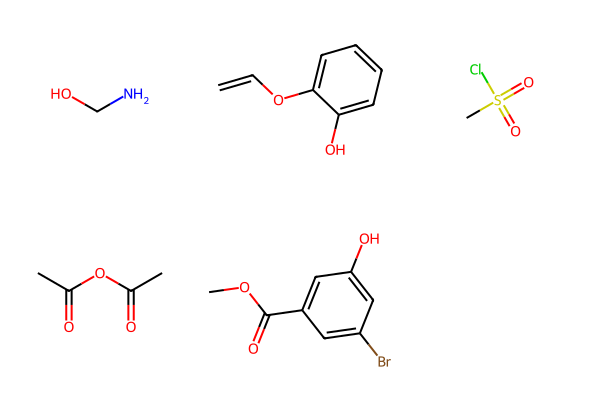

In [154]:
product_a_building_blocks = ["C(N)O", "C=COC1=C(C=CC=C1)O", "CS(=O)(=O)Cl" , "CC(=O)OC(=O)C", "COC(=O)C1=CC(=CC(=C1)O)Br"]

# canonialize smiles
product_a_building_blocks = [Chem.MolToSmiles(Chem.MolFromSmiles(smiles)) for smiles in product_a_building_blocks]

# visualize product_a_building_blocks

from rdkit.Chem import Draw
from rdkit import Chem

mols = [Chem.MolFromSmiles(smiles) for smiles in product_a_building_blocks]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(200,200))
img


In [155]:
# calculate the inchi keys for product_a_building_blocks
product_a_inchi_keys = [smiles_to_inchi_key(smiles) for smiles in product_a_building_blocks]
product_a_inchi_keys

['XMYQHJDBLRZMLW-UHFFFAOYSA-N',
 'AACJJTBDGOLJLL-UHFFFAOYSA-N',
 'QARBMVPHQWIHKH-UHFFFAOYSA-N',
 'WFDIJRYMOXRFFG-UHFFFAOYSA-N',
 'KRTBWIIGEJIUSA-UHFFFAOYSA-N']

In [156]:
# Product A building blocks and their InChI keys (already calculated)
product_a_building_blocks = ["C(N)O", "C=COC1=C(C=CC=C1)O", "CS(=O)(=O)Cl" , "CC(=O)OC(=O)C", "COC(=O)C1=CC(=CC(=C1)O)Br"]
product_a_inchi_keys = [smiles_to_inchi_key(smiles) for smiles in product_a_building_blocks]

print("Product A InChI keys:", product_a_inchi_keys)
print()

# Check across all algorithms for molecule 1 (index 0)
molecule_index = 0

for algorithm, df in all_building_blocks.items():
    print(f"\n{'='*60}")
    print(f"Algorithm: {algorithm}")
    print(f"{'='*60}")
    
    # Get molecule 1 data
    molecule_1 = df.iloc[molecule_index]
    target_smiles = molecule_1['target']
    
    print(f"Target molecule: {target_smiles}")
    
    # Check in unique_building_blocks_inchi_keys (total across all routes)
    unique_bb_inchi_keys = set(molecule_1['unique_building_blocks_inchi_keys'])
    total_matches = len([inchi for inchi in product_a_inchi_keys if inchi in unique_bb_inchi_keys])
    
    print(f"Total Product A matches across all routes: {total_matches}/{len(product_a_inchi_keys)}")
    
    # Find the route with the highest number of Product A matches
    nested_routes = molecule_1['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists']
    
    best_route_id = -1
    best_match_count = 0
    best_matching_inchi_keys = []
    
    for route_id, route in enumerate(nested_routes):
        route_matches = [inchi for inchi in product_a_inchi_keys if inchi in route]
        match_count = len(route_matches)
        
        if match_count > best_match_count:
            best_match_count = match_count
            best_route_id = route_id
            best_matching_inchi_keys = route_matches
    
    print(f"Best single route match: {best_match_count}/{len(product_a_inchi_keys)} (Route ID: {best_route_id})")
    
    if best_matching_inchi_keys:
        # Find corresponding SMILES for the best route
        best_matching_smiles = [product_a_building_blocks[product_a_inchi_keys.index(inchi)] 
                               for inchi in best_matching_inchi_keys]
        print(f"  Matching SMILES in best route: {best_matching_smiles}")
        print(f"  Matching InChI keys: {best_matching_inchi_keys}")

Product A InChI keys: ['XMYQHJDBLRZMLW-UHFFFAOYSA-N', 'AACJJTBDGOLJLL-UHFFFAOYSA-N', 'QARBMVPHQWIHKH-UHFFFAOYSA-N', 'WFDIJRYMOXRFFG-UHFFFAOYSA-N', 'KRTBWIIGEJIUSA-UHFFFAOYSA-N']


Algorithm: MCTS
Target molecule: CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1
Total Product A matches across all routes: 3/5
Best single route match: 3/5 (Route ID: 147)
  Matching SMILES in best route: ['C=COC1=C(C=CC=C1)O', 'CS(=O)(=O)Cl', 'COC(=O)C1=CC(=CC(=C1)O)Br']
  Matching InChI keys: ['AACJJTBDGOLJLL-UHFFFAOYSA-N', 'QARBMVPHQWIHKH-UHFFFAOYSA-N', 'KRTBWIIGEJIUSA-UHFFFAOYSA-N']

Algorithm: Distance-MCTS
Target molecule: CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1
Total Product A matches across all routes: 3/5
Best single route match: 3/5 (Route ID: 149)
  Matching SMILES in best route: ['C=COC1=C(C=CC=C1)O', 'CS(=O)(=O)Cl', 'COC(=O)C1=CC(=CC(=C1)O)Br']
  Matching InChI keys: ['AACJJTBDGOLJLL-UHFFFAOYSA-N', 'QARBMVPHQWIHKH-UHFFFAOYSA-N', 'KRTBWIIGEJIUSA-UHFFFAOYSA-N']

Algorithm: Cluster-MCTS
Targe

In [157]:
product_b_key_building_block = "CC(C)(C)OC(=O)N1CC2CC2(C1)C=O"
product_b_key_building_block = Chem.MolToSmiles(Chem.MolFromSmiles(product_b_key_building_block))
product_b_key_building_block_inchi = smiles_to_inchi_key(product_b_key_building_block)
product_b_key_building_block_inchi

'PUTOENHGHDTSSY-UHFFFAOYSA-N'

In [158]:
recalculate_emolecules = True
emolecules = "/Users/alankaihassen/development/diversity_search_rebuttal/updated_code/data/stocks/full_building_blocks/dual_value_networks_emolecules_stock.hdf5"
emolecules = pd.read_hdf(emolecules, key = "table")
emolecules


,inchi_key
0,POCJYUOGKGCBBV-UHFFFAOYSA-N
1,QBIDXIPTVVOXGR-UHFFFAOYSA-N
2,PYOZSVSWLQWZBM-UHFFFAOYSA-N
3,WOGOAGNXDFKJPJ-UHFFFAOYSA-N
4,PDJHGQDZISNXBQ-UHFFFAOYSA-N
...,...
23081624,FWLOYEOGPQTDEN-UHFFFAOYSA-N
23081625,AXTPHTDFPNBTMW-UHFFFAOYSA-N
23081626,KEWQPSFXRIHNEJ-UHFFFAOYSA-N
23081627,WIFZGSRQGPRMFE-UHFFFAOYSA-N


In [159]:
# check if product_b_key_building_block_inchi is in emolecules inchi keys
emolecules_inchi_keys = set(emolecules['inchi_key'])
product_b_key_building_block_inchi in emolecules_inchi_keys

True

In [160]:
selected_original_columns = []

In [161]:
import pandas as pd

def create_molecule_summary_table(all_building_blocks, methods):
    """
    Create a summary table with key statistics for each molecule and algorithm.
    
    Parameters:
    -----------
    all_building_blocks : dict
        Dictionary mapping algorithm names to DataFrames with building block data
    methods : list
        List of method names (algorithm order)
    
    Returns:
    --------
    pd.DataFrame : Summary table with columns:
        - molecule_id
        - target
        - algorithm
        - is_solved
        - max_transforms
        - number_of_steps (smallest number of reactions in best route)
        - tree_solved_routes (before hash deduplication)
        - hash_deduplicated_routes (after hash deduplication)
        - bb_deduplicated_routes (after building block set deduplication)
        - min_building_blocks_per_route
        - total_unique_building_blocks
    """
    
    results = []
    
    # Get number of molecules (assume all methods have the same molecules)
    num_molecules = len(all_building_blocks[methods[0]])
    
    for molecule_index in range(num_molecules):
        for method in methods:
            df = all_building_blocks[method]
            molecule_data = df.iloc[molecule_index]
            
            # Basic info
            target = molecule_data['target']
            is_solved = molecule_data['is_solved']
            max_transforms = molecule_data['max_transforms']
            
            # Number of steps (smallest number of reactions)
            number_of_steps = molecule_data['number_of_steps'] if is_solved else None
            
            # Route counts at different stages
            tree_solved_routes = molecule_data['number_of_solved_routes']  # Before hash deduplication
            hash_deduplicated_routes = molecule_data['num_routes_original']  # After hash deduplication
            bb_deduplicated_routes = molecule_data['num_routes_deduplicated']  # After BB set deduplication
            
            # Building block statistics
            nested_routes = molecule_data['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists']
            
            if nested_routes and len(nested_routes) > 0:
                min_building_blocks_per_route = min(len(route) for route in nested_routes)
            else:
                min_building_blocks_per_route = None
            
            total_unique_building_blocks = molecule_data['num_unique_building_blocks']
            
            results.append({
                'molecule_id': molecule_index,
                'target': target,
                'algorithm': method,
                'is_solved': is_solved,
                'max_transforms': max_transforms,
                'number_of_steps': number_of_steps,
                'tree_solved_routes': tree_solved_routes,
                'hash_deduplicated_routes': hash_deduplicated_routes,
                'bb_deduplicated_routes': bb_deduplicated_routes,
                'min_unique_building_blocks_in_routes': min_building_blocks_per_route,
                'total_unique_building_blocks': total_unique_building_blocks
            })
    
    # Create DataFrame
    summary_df = pd.DataFrame(results)
    
    # Sort by molecule_id and algorithm order
    summary_df['algorithm'] = pd.Categorical(summary_df['algorithm'], categories=methods, ordered=True)
    summary_df = summary_df.sort_values(['molecule_id', 'algorithm']).reset_index(drop=True)
    
    return summary_df


def create_molecule_summary_table_wide(all_building_blocks, methods):
    """
    Create a wide-format summary table with algorithms as columns.
    
    Parameters:
    -----------
    all_building_blocks : dict
        Dictionary mapping algorithm names to DataFrames with building block data
    methods : list
        List of method names (algorithm order)
    
    Returns:
    --------
    pd.DataFrame : Wide-format summary table
    """
    
    # Get the long format first
    long_df = create_molecule_summary_table(all_building_blocks, methods)
    
    # Pivot to wide format for easier comparison
    wide_dfs = []
    
    metrics = ['is_solved', 'max_transforms', 'number_of_steps',
               'tree_solved_routes', 'hash_deduplicated_routes', 'bb_deduplicated_routes',
               'min_unique_building_blocks_in_routes', 'total_unique_building_blocks']
    
    for metric in metrics:
        pivot = long_df.pivot(index=['molecule_id', 'target'], 
                              columns='algorithm', 
                              values=metric)
        pivot.columns = [f'{metric}_{col}' for col in pivot.columns]
        wide_dfs.append(pivot)
    
    # Combine all pivoted dataframes
    wide_df = pd.concat(wide_dfs, axis=1).reset_index()
    
    return wide_df


# Example usage:
# Long format (one row per molecule-algorithm combination)
summary_table = create_molecule_summary_table(all_building_blocks, algorithm_order)
print("Long format summary table:")
display(summary_table)

Long format summary table:


,molecule_id,target,algorithm,is_solved,max_transforms,number_of_steps,tree_solved_routes,hash_deduplicated_routes,bb_deduplicated_routes,min_unique_building_blocks_in_routes,total_unique_building_blocks
0,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,MCTS,True,30,3.0,2167,1976,1181,4.0,180
1,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,Distance-MCTS,True,30,3.0,3322,2737,1301,4.0,231
2,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,Cluster-MCTS,True,30,4.0,976,659,466,4.0,115
3,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,Retro*-0,True,13,4.0,836,836,758,4.0,121
4,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,Cluster-Retro*-0,True,22,6.0,1042,1042,620,5.0,215
5,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,MCTS,True,30,4.0,2,2,2,5.0,12
6,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,Distance-MCTS,True,30,4.0,21,16,14,4.0,19
7,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,Cluster-MCTS,True,30,6.0,5,3,3,5.0,11
8,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,Retro*-0,True,17,5.0,11,11,11,5.0,19
9,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,Cluster-Retro*-0,False,30,NaN,0,0,0,NaN,0


In [ ]:
summary_table[["molecule_id", "algorithm", "is_solved", "hash_deduplicated_routes", "bb_deduplicated_routes", "min_unique_building_blocks_in_routes", "total_unique_building_blocks"]]
# Note: Number of reactions from the visualizations below because azf number of steps is the shortest route with the highest score but not neccessarily the route with the least number of reactions.

,molecule_id,algorithm,is_solved,hash_deduplicated_routes,bb_deduplicated_routes,min_unique_building_blocks_in_routes,total_unique_building_blocks
0,0,MCTS,True,1976,1181,4.0,180
1,0,Distance-MCTS,True,2737,1301,4.0,231
2,0,Cluster-MCTS,True,659,466,4.0,115
3,0,Retro*-0,True,836,758,4.0,121
4,0,Cluster-Retro*-0,True,1042,620,5.0,215
5,1,MCTS,True,2,2,5.0,12
6,1,Distance-MCTS,True,16,14,4.0,19
7,1,Cluster-MCTS,True,3,3,5.0,11
8,1,Retro*-0,True,11,11,5.0,19
9,1,Cluster-Retro*-0,False,0,0,NaN,0


In [163]:
import pandas as pd

# --- Start of code to generate the LaTeX table ---
# This code assumes 'summary_table' is your existing DataFrame.

# 1. Define the columns you want in the final table
columns_to_include = [
    "molecule_id", 
    "algorithm", 
    "is_solved",
    "number_of_steps", 
    "hash_deduplicated_routes", 
    "bb_deduplicated_routes", 
    "min_unique_building_blocks_in_routes",
    "total_unique_building_blocks"
]
df_subset = summary_table[columns_to_include]

# 2. Define LaTeX table structure and headers
caption = "Detailed Synthesis Route Search Results per Molecule"
label = "tab:summary_results_detailed"
table_width = "\\textwidth"

# Explicitly define the multi-line headers for clarity
header_map = {
    'molecule_id': r'\makecell[c]{Molecule \\ ID}',
    'algorithm': r'\textbf{Algorithm}',
    'is_solved': r'\makecell[c]{Is \\ Solved}',
    'number_of_steps': r'\makecell[c]{Num \\ Steps}',
    'hash_deduplicated_routes': r'\makecell[c]{Hash Dedup. \\ Routes}',
    'bb_deduplicated_routes': r'\makecell[c]{BB Dedup. \\ Routes}',
    'min_unique_building_blocks_in_routes': r'\makecell[c]{Min BBs \\ in Route}',
    'total_unique_building_blocks': r'\makecell[c]{Total \\ Unique BBs}'
}

# Create the list of headers for the table
headers = [header_map[col] for col in df_subset.columns]

# Define column alignment: 'l' for algorithm, 'c' for the rest
col_format = f"@{{\\extracolsep{{\\fill}}}}cl{'c' * (len(df_subset.columns) - 2)}"

# 3. Build the LaTeX string
latex_parts = [
    "\\begin{table}[h]",
    "\\centering",
    f"\\caption{{{caption}}}",
    f"\\label{{{label}}}",
    f"\\begin{{tabular*}}{{{table_width}}}{{{col_format}}}",
    "\\toprule",
    " & ".join(headers) + " \\\\",
    "\\midrule"
]

# Add data rows from the DataFrame
for _, row in df_subset.iterrows():
    # Convert each item in the row to a string, handling potential None/NaN values
    row_values = [str(item) if pd.notna(item) else '' for item in row]
    latex_parts.append(" & ".join(row_values) + " \\\\")

# Add footer and closing tags
latex_parts.extend([
    "\\bottomrule",
    "\\end{tabular*}",
    "\\end{table}"
])

latex_string = "\n".join(latex_parts)

# --- Print the result ---
print("\n--- Generated LaTeX Code ---")
print(latex_string)
print("\nNOTE: Ensure your LaTeX document includes \\usepackage{booktabs} and \\usepackage{makecell}.")

# --- Optionally, save the file ---
output_path = "/Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/plots/detailed_summary_table.tex"
try:
    with open(output_path, 'w') as f:
        f.write(latex_string)
    print(f"\nLaTeX table successfully saved to {output_path}")
except Exception as e:
    print(f"\nError saving file: {e}")


--- Generated LaTeX Code ---
\begin{table}[h]
\centering
\caption{Detailed Synthesis Route Search Results per Molecule}
\label{tab:summary_results_detailed}
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}}clcccccc}
\toprule
\makecell[c]{Molecule \\ ID} & \textbf{Algorithm} & \makecell[c]{Is \\ Solved} & \makecell[c]{Num \\ Steps} & \makecell[c]{Hash Dedup. \\ Routes} & \makecell[c]{BB Dedup. \\ Routes} & \makecell[c]{Min BBs \\ in Route} & \makecell[c]{Total \\ Unique BBs} \\
\midrule
0 & MCTS & True & 3.0 & 1976 & 1181 & 4.0 & 180 \\
0 & Distance-MCTS & True & 3.0 & 2737 & 1301 & 4.0 & 231 \\
0 & Cluster-MCTS & True & 4.0 & 659 & 466 & 4.0 & 115 \\
0 & Retro*-0 & True & 4.0 & 836 & 758 & 4.0 & 121 \\
0 & Cluster-Retro*-0 & True & 6.0 & 1042 & 620 & 5.0 & 215 \\
1 & MCTS & True & 4.0 & 2 & 2 & 5.0 & 12 \\
1 & Distance-MCTS & True & 4.0 & 16 & 14 & 4.0 & 19 \\
1 & Cluster-MCTS & True & 6.0 & 3 & 3 & 5.0 & 11 \\
1 & Retro*-0 & True & 5.0 & 11 & 11 & 5.0 & 19 \\
1 & Cluster-Retro*-0 &

## visualizations

Target molecule: CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1
MCTS: 180 unique building blocks
Distance-MCTS: 231 unique building blocks
Cluster-MCTS: 115 unique building blocks
Retro*-0: 121 unique building blocks
Cluster-Retro*-0: 215 unique building blocks

Total unique building blocks across all methods: 434

Generating all algorithm combinations and calculating union coverage...
Generated 31 combinations (expected: 31)

Creating UpSet plot (Union Coverage % on Top, Absolute Counts on Left)...

Plot saved to /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/plots/molecule_Product A_building_blocks_upset_plot.pdf

Plot saved to /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/plots/molecule_Product A_building_blocks_upset_plot.pdf


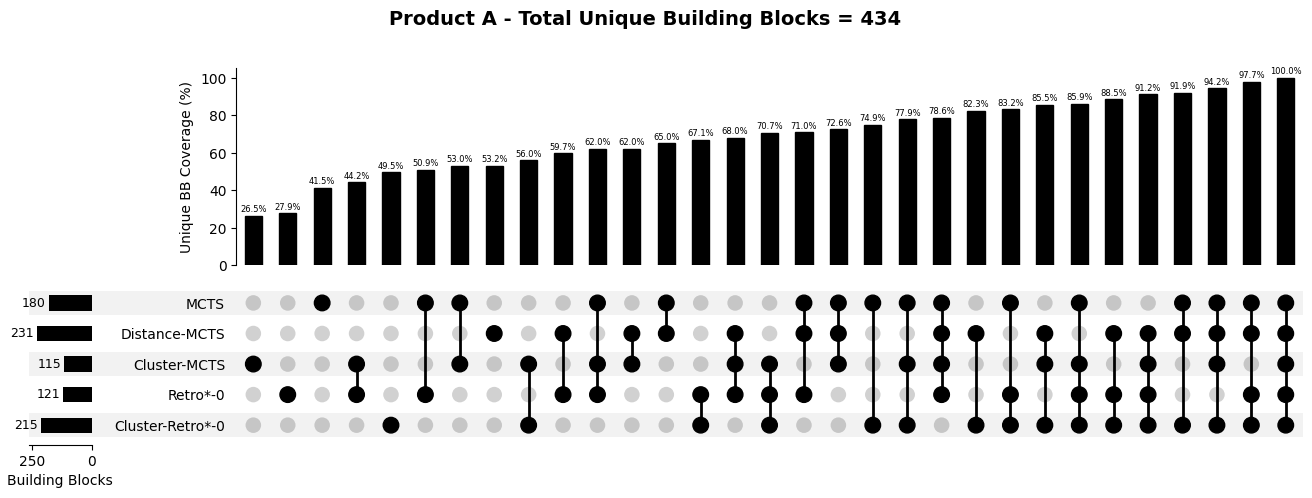


VERIFICATION: Left bar values (absolute BB counts per algorithm)
MCTS: 180 unique building blocks
Distance-MCTS: 231 unique building blocks
Cluster-MCTS: 115 unique building blocks
Retro*-0: 121 unique building blocks
Cluster-Retro*-0: 215 unique building blocks


{'all_bbs_per_method': {'MCTS': {'AACJJTBDGOLJLL-UHFFFAOYSA-N',
   'AFVFQIVMOAPDHO-UHFFFAOYSA-N',
   'AGEZXYOZHKGVCM-UHFFFAOYSA-N',
   'BAVYZALUXZFZLV-UHFFFAOYSA-N',
   'BCLZHRBOXZTZIO-UHFFFAOYSA-N',
   'BCNZYOJHNLTNEZ-UHFFFAOYSA-N',
   'BGSHMIKKQYYGHN-UHFFFAOYSA-N',
   'BHELZAPQIKSEDF-UHFFFAOYSA-N',
   'BUDQDWGNQVEFAC-UHFFFAOYSA-N',
   'BVKZGUZCCUSVTD-UHFFFAOYSA-L',
   'BVKZGUZCCUSVTD-UHFFFAOYSA-M',
   'CCZCXFHJMKINPE-UHFFFAOYSA-N',
   'CELWCAITJAEQNL-UHFFFAOYSA-N',
   'CFHJXQLPUIYWNM-UHFFFAOYSA-N',
   'CISPWLGTLAYSDM-UHFFFAOYSA-N',
   'CROMNVSVLZKBEF-UHFFFAOYSA-N',
   'CSCPPACGZOOCGX-UHFFFAOYSA-N',
   'CSPLGDDGIJDAJS-UHFFFAOYSA-N',
   'CTSLXHKWHWQRSH-UHFFFAOYSA-N',
   'CURLTUGMZLYLDI-UHFFFAOYSA-N',
   'DIOHEXPTUTVCNX-UHFFFAOYSA-N',
   'DNJRKFKAFWSXSE-UHFFFAOYSA-N',
   'DTQVDTLACAAQTR-UHFFFAOYSA-N',
   'DZCQREFAFYAXTL-UHFFFAOYSA-N',
   'FJGATDISEXKPPR-UHFFFAOYSA-N',
   'FWIROFMBWVMWLB-UHFFFAOYSA-N',
   'GCHMYKMWYBHYSV-UHFFFAOYSA-N',
   'GDTBXPJZTBHREO-UHFFFAOYSA-N',
   'GFROXMGZVLABNJ

In [164]:
import matplotlib.pyplot as plt
from upsetplot import UpSet
import pandas as pd
from itertools import combinations

def create_upset_plot_for_molecule(all_building_blocks, molecule_index, methods, molecule_name=None, save_path=None, save_plot=False):
    """
    Create an UpSet plot showing building block UNION coverage for a specific molecule.
    """
    
    # ==============================================================================
    # STEP 1: Get all unique building blocks per method for the selected molecule
    # ==============================================================================

    print(f"Collecting building blocks for molecule {molecule_index}...")

    all_bbs_per_method = {}
    target_smiles = None

    if not molecule_name:
        molecule_name = f"Molecule {molecule_index}"

    for method in methods:
        df = all_building_blocks[method]
        molecule_data = df.iloc[molecule_index]
        
        if target_smiles is None:
            target_smiles = molecule_data['target']
            print(f"Target molecule: {target_smiles}")
        
        # Get unique InChI keys for this molecule and method
        inchi_keys = set(molecule_data['unique_building_blocks_inchi_keys'])
        all_bbs_per_method[method] = inchi_keys
        print(f"{method}: {len(inchi_keys)} unique building blocks")

    # Calculate total unique BBs across ALL methods for this molecule
    all_bbs_combined = set()
    for bbs in all_bbs_per_method.values():
        all_bbs_combined.update(bbs)

    total_unique_bbs = len(all_bbs_combined)
    print(f"\nTotal unique building blocks across all methods: {total_unique_bbs}")

    # ==============================================================================
    # STEP 2: Generate ALL 2^n - 1 combinations and calculate UNION coverage
    # ==============================================================================

    print("\nGenerating all algorithm combinations and calculating union coverage...")

    # For UpSet plot matrix display (top to bottom):
    # MCTS at top, Cluster-Retro*-0 at bottom
    # Reverse the methods order for correct display
    methods_for_upset = list(reversed(methods))
    
    all_combinations = []
    union_coverages = []
    
    for r in range(1, len(methods_for_upset) + 1):
        for combo in combinations(methods_for_upset, r):
            all_combinations.append(combo)
            
            # Calculate UNION of building blocks for this combination
            union_bbs = set()
            for method in combo:
                union_bbs.update(all_bbs_per_method[method])
            
            # Calculate coverage percentage
            coverage_pct = (len(union_bbs) / total_unique_bbs) * 100 if total_unique_bbs > 0 else 0
            union_coverages.append(coverage_pct)
    
    print(f"Generated {len(all_combinations)} combinations (expected: {2**len(methods) - 1})")

    # ==============================================================================
    # STEP 3: Create Series for UpSet plot
    # ==============================================================================

    index_tuples = []
    for combo in all_combinations:
        row = tuple(method in combo for method in methods_for_upset)
        index_tuples.append(row)
        
    multi_index = pd.MultiIndex.from_tuples(index_tuples, names=methods_for_upset)
    upset_data = pd.Series(union_coverages, index=multi_index)
    upset_data = upset_data.sort_values(ascending=True)

    # ==============================================================================
    # STEP 4: Create UpSet plot with MANUAL Totals Replacement
    # ==============================================================================

    print("\nCreating UpSet plot (Union Coverage % on Top, Absolute Counts on Left)...")

    # Initialize UpSet
    # Note: We let it generate the 'totals' incorrectly initially, then we fix it below.
    upset = UpSet(
        upset_data,
        subset_size='sum',
        show_counts='%.1f%%',
        sort_by=None,
        sort_categories_by='input'
    )
    
    fig = plt.figure(figsize=(16, 8))

    # 1. Generate the base plot
    axes_dict = upset.plot(fig=fig)
    
    # --------------------------------------------------------------------------
    # CRITICAL FIX 1: Manually redraw the Left (Totals) Bar Chart
    # --------------------------------------------------------------------------
    
    ax_totals = axes_dict['totals']
    
    # Clear the incorrect "percentage sum" bars
    ax_totals.clear()
    
    # Prepare the correct absolute counts
    # 'methods_for_upset' is already in the order (Bottom -> Top) used by the matrix rows
    counts_in_order = [len(all_bbs_per_method[m]) for m in methods_for_upset]
    y_positions = range(len(methods_for_upset))
    
    # Plot the bars manually
    # We use zorder=10 to ensure bars are drawn on top if there's overlap, 
    # but facecolor='none' on axis ensures we don't hide anything behind the axis.
    bars = ax_totals.barh(
        y_positions, 
        counts_in_order, 
        height=0.5, 
        color="#000000",  # Standard gray
        align='center'
    )
    
    # Set Axis Limits: Max count + Padding
    max_count = max(counts_in_order) if counts_in_order else 0
    if max_count == 0:
        x_limit = 10
    else:
        x_limit = max_count * 1.15
    
    # INVERT the axis (High -> Low) so bars grow from Right to Left
    # This aligns the "base" of the bars with the matrix on the right.
    ax_totals.set_xlim(x_limit, 0)
    
    # Clean up styling to match UpSet look
    ax_totals.grid(False)
    ax_totals.spines['top'].set_visible(False)
    ax_totals.spines['left'].set_visible(False)
    ax_totals.spines['right'].set_visible(False) # This is the spine touching the matrix
    
    # Ensure background is transparent so it doesn't mask neighboring labels
    ax_totals.set_facecolor('none')
    
    # Remove Y ticks from totals (we will put labels on the matrix axis instead)
    ax_totals.set_yticks(y_positions)
    ax_totals.set_yticklabels([]) 
    ax_totals.tick_params(axis='y', length=0)
    
    # Add labels to the bars
    for i, bar in enumerate(bars):
        count = counts_in_order[i]
        # Position label at the end of the bar (visually to the left)
        label_x_pos = count + (x_limit * 0.05)
        
        ax_totals.text(
            label_x_pos, 
            bar.get_y() + bar.get_height()/2, 
            f'{count}', 
            va='center', 
            ha='right', 
            fontsize=9
        )
    
    # --------------------------------------------------------------------------
    # CRITICAL FIX 2: Explicitly Set Labels on Matrix Axis
    # --------------------------------------------------------------------------
    # The row descriptions are on the 'matrix' axis.
    ax_matrix = axes_dict['matrix']
    
    # Force the ticks and labels to exist
    ax_matrix.set_yticks(y_positions)
    ax_matrix.set_yticklabels(methods_for_upset)
    
    # Adjust styling:
    # labelleft=True: ensures labels are on the left of the matrix
    # pad=8: Sets a moderate distance. Smaller than default, but large enough to not overlap dots.
    # labelsize=10: Ensures text is readable
    ax_matrix.tick_params(axis='y', which='both', labelleft=True, pad=8, labelsize=10)
    
    # --------------------------------------------------------------------------
    # End of Manual Fixes
    # --------------------------------------------------------------------------

    # Style the rest of the plot
    axes_dict['intersections'].grid(False)
    
    # Make the intersection labels smaller
    for text in axes_dict['intersections'].texts:
        text.set_fontsize(6)

    # Update axis labels
    axes_dict['intersections'].set_ylabel('Unique BB Coverage (%)')
    ax_totals.set_xlabel('Building Blocks')

    # Update title
    plt.suptitle(f'{molecule_name} - Total Unique Building Blocks = {total_unique_bbs:,}', 
                 fontsize=14, fontweight='bold', y=1.0)

    if save_plot and save_path:
        plot_filename = f"{save_path}/molecule_{molecule_name}_building_blocks_upset_plot.pdf"
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to {plot_filename}")
    
    plt.show()
    
    print("\n" + "="*80)
    print("VERIFICATION: Left bar values (absolute BB counts per algorithm)")
    print("="*80)
    for method in methods:
        print(f"{method}: {len(all_bbs_per_method[method])} unique building blocks")
    
    return {
        'all_bbs_per_method': all_bbs_per_method,
        'total_unique_bbs': total_unique_bbs,
        'target_smiles': target_smiles,
        'num_combinations': len(all_combinations)
    }
# For molecule 0
save_path = "/Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/plots"
result_mol0 = create_upset_plot_for_molecule(all_building_blocks, molecule_index=0, methods=algorithm_order,molecule_name= "Product A" ,save_path=save_path, save_plot=True)
result_mol0

Target molecule: CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F)(F)F)on2)C1)C(F)(F)F
MCTS: 12 unique building blocks
Distance-MCTS: 19 unique building blocks
Cluster-MCTS: 11 unique building blocks
Retro*-0: 19 unique building blocks
Cluster-Retro*-0: 0 unique building blocks

Total unique building blocks across all methods: 35

Generating all algorithm combinations and calculating union coverage...
Generated 31 combinations (expected: 31)

Creating UpSet plot (Union Coverage % on Top, Absolute Counts on Left)...

Plot saved to /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/plots/molecule_Product B_building_blocks_upset_plot.pdf

Plot saved to /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/plots/molecule_Product B_building_blocks_upset_plot.pdf


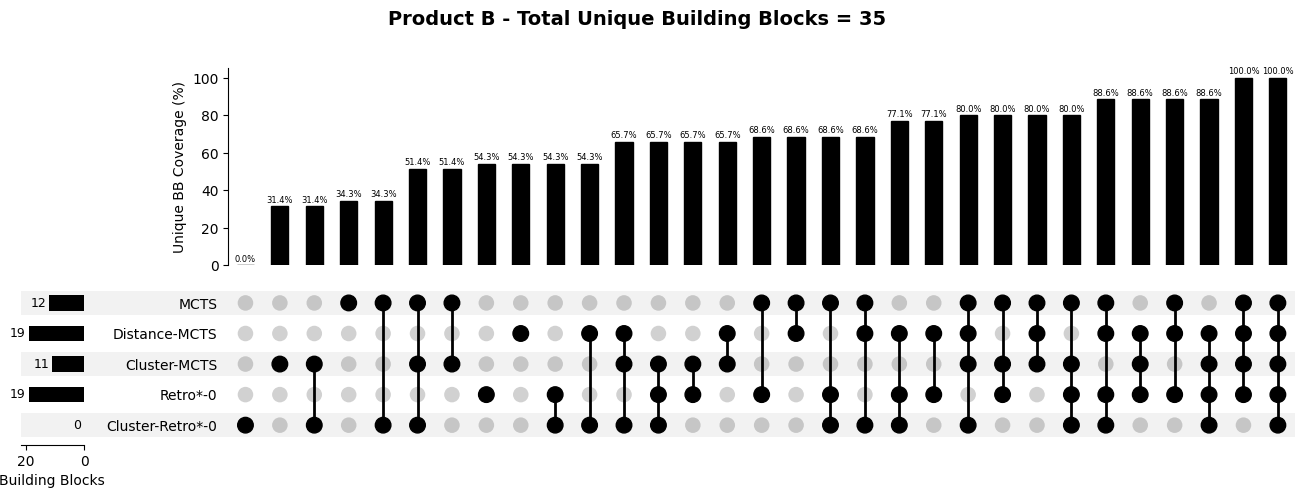


VERIFICATION: Left bar values (absolute BB counts per algorithm)
MCTS: 12 unique building blocks
Distance-MCTS: 19 unique building blocks
Cluster-MCTS: 11 unique building blocks
Retro*-0: 19 unique building blocks
Cluster-Retro*-0: 0 unique building blocks


{'all_bbs_per_method': {'MCTS': {'AGEZXYOZHKGVCM-UHFFFAOYSA-N',
   'BRLQWZUYTZBJKN-UHFFFAOYSA-N',
   'CHKRMHVYJKDKSZ-UHFFFAOYSA-N',
   'DYHSDKLCOJIUFX-UHFFFAOYSA-N',
   'GILIYJDBJZWGBG-UHFFFAOYSA-N',
   'GRYLNZFGIOXLOG-UHFFFAOYSA-N',
   'HSDAJNMJOMSNEV-UHFFFAOYSA-N',
   'NZZFYRREKKOMAT-UHFFFAOYSA-N',
   'OIZXJJIHVIYNKZ-UHFFFAOYSA-N',
   'QNRHCAQNLPLUOM-UHFFFAOYSA-N',
   'SKWDIXBVQATQSG-UHFFFAOYSA-N',
   'XMBWDFGMSWQBCA-UHFFFAOYSA-M'},
  'Distance-MCTS': {'ACBAHAXPEQHVHO-UHFFFAOYSA-N',
   'BVJQZAHQFKJQSQ-UHFFFAOYSA-N',
   'BXWLVQXAFBWKSR-UHFFFAOYSA-N',
   'CCCKOEYCRHBDDH-UHFFFAOYSA-N',
   'CURLTUGMZLYLDI-UHFFFAOYSA-N',
   'DYHSDKLCOJIUFX-UHFFFAOYSA-N',
   'GILIYJDBJZWGBG-UHFFFAOYSA-N',
   'JRNVZBWKYDBUCA-UHFFFAOYSA-N',
   'LVCOOUAQCQKOJG-UHFFFAOYSA-N',
   'NZZFYRREKKOMAT-UHFFFAOYSA-N',
   'OIZXJJIHVIYNKZ-UHFFFAOYSA-N',
   'OKKJLVBELUTLKV-UHFFFAOYSA-N',
   'PNDPGZBMCMUPRI-UHFFFAOYSA-N',
   'QNRHCAQNLPLUOM-UHFFFAOYSA-N',
   'QOSVPLTVKMHNQV-UHFFFAOYSA-N',
   'RRDBQTDHQONBBG-UHFFFAOYSA-N',


In [165]:
result_mol1 = create_upset_plot_for_molecule(all_building_blocks, molecule_index=1, methods=algorithm_order,molecule_name= "Product B" ,save_path=save_path, save_plot=True)
result_mol1

# Check if product_b_key_building_block_inchi is found by any algorithm for molecule 1

In [166]:
molecule_index = 1

print(f"Checking for Product B key building block: {product_b_key_building_block}")
print(f"InChI key: {product_b_key_building_block_inchi}")
print()

for algorithm, df in all_building_blocks.items():
    molecule_data = df.iloc[molecule_index]
    target_smiles = molecule_data['target']
    
    # Check in unique_building_blocks_inchi_keys
    unique_bb_inchi_keys = set(molecule_data['unique_building_blocks_inchi_keys'])
    found = product_b_key_building_block_inchi in unique_bb_inchi_keys
    
    print(f"{algorithm}: {'✓ FOUND' if found else '✗ NOT FOUND'}")
    
    if found:
        # Find which routes contain this building block
        nested_routes = molecule_data['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists']
        routes_with_bb = [i for i, route in enumerate(nested_routes) if product_b_key_building_block_inchi in route]
        print(f"  - Found in {len(routes_with_bb)} route(s): {routes_with_bb}")

Checking for Product B key building block: CC(C)(C)OC(=O)N1CC2CC2(C=O)C1
InChI key: PUTOENHGHDTSSY-UHFFFAOYSA-N

MCTS: ✗ NOT FOUND
Distance-MCTS: ✗ NOT FOUND
Cluster-MCTS: ✗ NOT FOUND
Retro*-0: ✗ NOT FOUND
Cluster-Retro*-0: ✗ NOT FOUND


In [167]:
#break

# ROUTE VISUALIZATION

In [168]:
diversity_mcts = "/Users/alankaihassen/development/diversity_search_rebuttal/round2/zipotli/1_zipotli_diversity_mcts/results/1_zipotli_diversity_mcts.hdf"

import pandas

diversity_mcts_df = pandas.read_hdf(diversity_mcts, key="table")
diversity_mcts_df

,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,number_of_precursors,number_of_precursors_in_stock,precursors_in_stock,precursors_not_in_stock,precursors_availability,policy_used_counts,profiling,stock_info,top_scores,trees
0,0,CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1,3583.103695,141.199301,1,278374,30,116,266947,3322,...,4,4,"CS(=O)(=O)Cl, C=O, C=COc1ccccc1O, NC(=O)c1cc(O...",,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 278373},"{'expansion_calls': 11474, 'reactants_generati...","{'CS(=O)(=O)Cl': ['emolecules'], 'C=O': ['emol...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[{'type': 'mol', 'hide': False, 'smiles': 'CS(..."
1,1,CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F...,2208.021843,0.000000,0,175132,30,99,163481,21,...,5,5,"CC(O)C(F)(F)F, CS(=O)(=O)c1ccc(Cl)c(C(=O)O)c1,...",,emolecules;emolecules;emolecules;emolecules;em...,{'retrostar_mlp': 175131},"{'expansion_calls': 11958, 'reactants_generati...","{'CC(O)C(F)(F)F': ['emolecules'], 'CS(=O)(=O)c...","0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9634...","[{'type': 'mol', 'hide': False, 'smiles': 'CC(..."


/Users/alankaihassen/miniforge3/envs/sprs/lib/python3.10/site-packages/lightning_utilities/core/imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/alankaihassen/miniforge3/envs/sprs/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/Users/alankaihassen/miniforge3/envs/sprs/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIxEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  Referenced from: <61623A3D-DA3C-3AAD-B2F0-D363151DDB3F> /Users/alankaihassen/miniforge3/envs/sprs/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <44B645FB-F027

Processing: Molecule 0 (CS(=O)(=O)Oc1ccccc1O/C=C/c1cc(O)cc(C(=O)NCO)c1) | Route 2


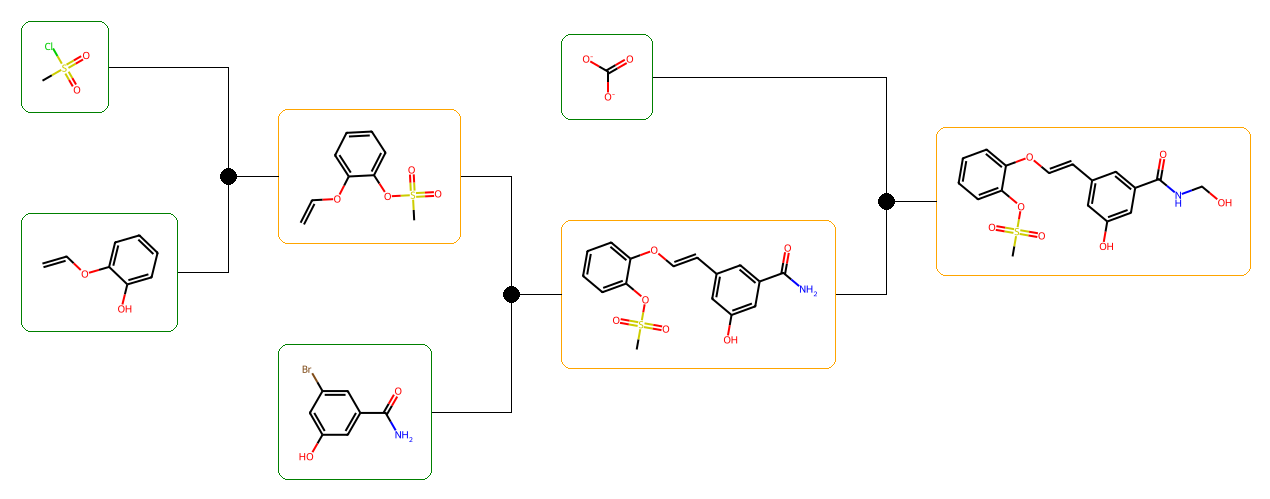

In [169]:
import pandas as pd
from aizynthfinder.reactiontree import ReactionTree
from IPython.display import display, Image
from typing import Optional, Union
from pathlib import Path

def visualize_route(
    df: pd.DataFrame, 
    molecule_index: int, 
    route_index: int, 
    show_image: bool = True,
    save_path: Optional[str] = None
) -> Optional[Union[Image, object]]:
    """
    Extracts a reaction tree from a dataframe, visualizes it, and optionally saves it.

    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing the results (must have a 'trees' column).
    molecule_index : int
        The row index of the molecule.
    route_index : int
        The index of the route within the 'trees' list.
    show_image : bool
        If True, calls display() on the image immediately.
    save_path : str, optional
        If provided, saves the image to this file path (e.g. "output/route.png").

    Returns:
    --------
    Image object or None if an error occurs.
    """
    
    # 1. Validate Molecule Index
    if molecule_index < 0 or molecule_index >= len(df):
        print(f"❌ Error: Molecule index {molecule_index} is out of bounds (0-{len(df)-1}).")
        return None

    # 2. Extract Row Data
    try:
        molecule_data = df.iloc[molecule_index]
        target_smiles = molecule_data.get('target', 'Unknown Target')
        routes_list = molecule_data.get('trees')
    except Exception as e:
        print(f"❌ Error accessing dataframe data: {e}")
        return None

    # 3. Validate Routes Data
    if not isinstance(routes_list, list) or not routes_list:
        print(f"❌ Error: No routes found for molecule {molecule_index} ({target_smiles}).")
        return None

    # 4. Validate Route Index
    if route_index < 0 or route_index >= len(routes_list):
        print(f"❌ Error: Route index {route_index} is out of bounds for this molecule (0-{len(routes_list)-1}).")
        return None

    # 5. Build, Display, and Save
    print(f"Processing: Molecule {molecule_index} ({target_smiles}) | Route {route_index}")
    
    try:
        route_data = routes_list[route_index]
        route = ReactionTree.from_dict(route_data)
        image = route.to_image()
        
        # Save to Disk
        if save_path:
            path_obj = Path(save_path)
            # Create parent directories if they don't exist
            path_obj.parent.mkdir(parents=True, exist_ok=True)
            
            # Write binary data to file
            with open(path_obj, "wb") as f:
                f.write(image.data)
            print(f"✅ Saved image to: {path_obj.resolve()}")
            
        return image

    except Exception as e:
        print(f"❌ Error processing reaction tree: {e}")
        return None

# --- Usage Examples ---

# Option A: Just view it
visualize_route(diversity_mcts_df, molecule_index=0, route_index=2)

# Option B: View and Save
#visualize_route(diversity_mcts_df, molecule_index=0, route_index=0,                 save_path="results/mol0_route0.png")

Processing: Molecule 1 (CC(Oc1ccc(S(C)(=O)=O)cc1C(=O)N1CC2CC2(c2cc(C(F)(F)F)on2)C1)C(F)(F)F) | Route 0


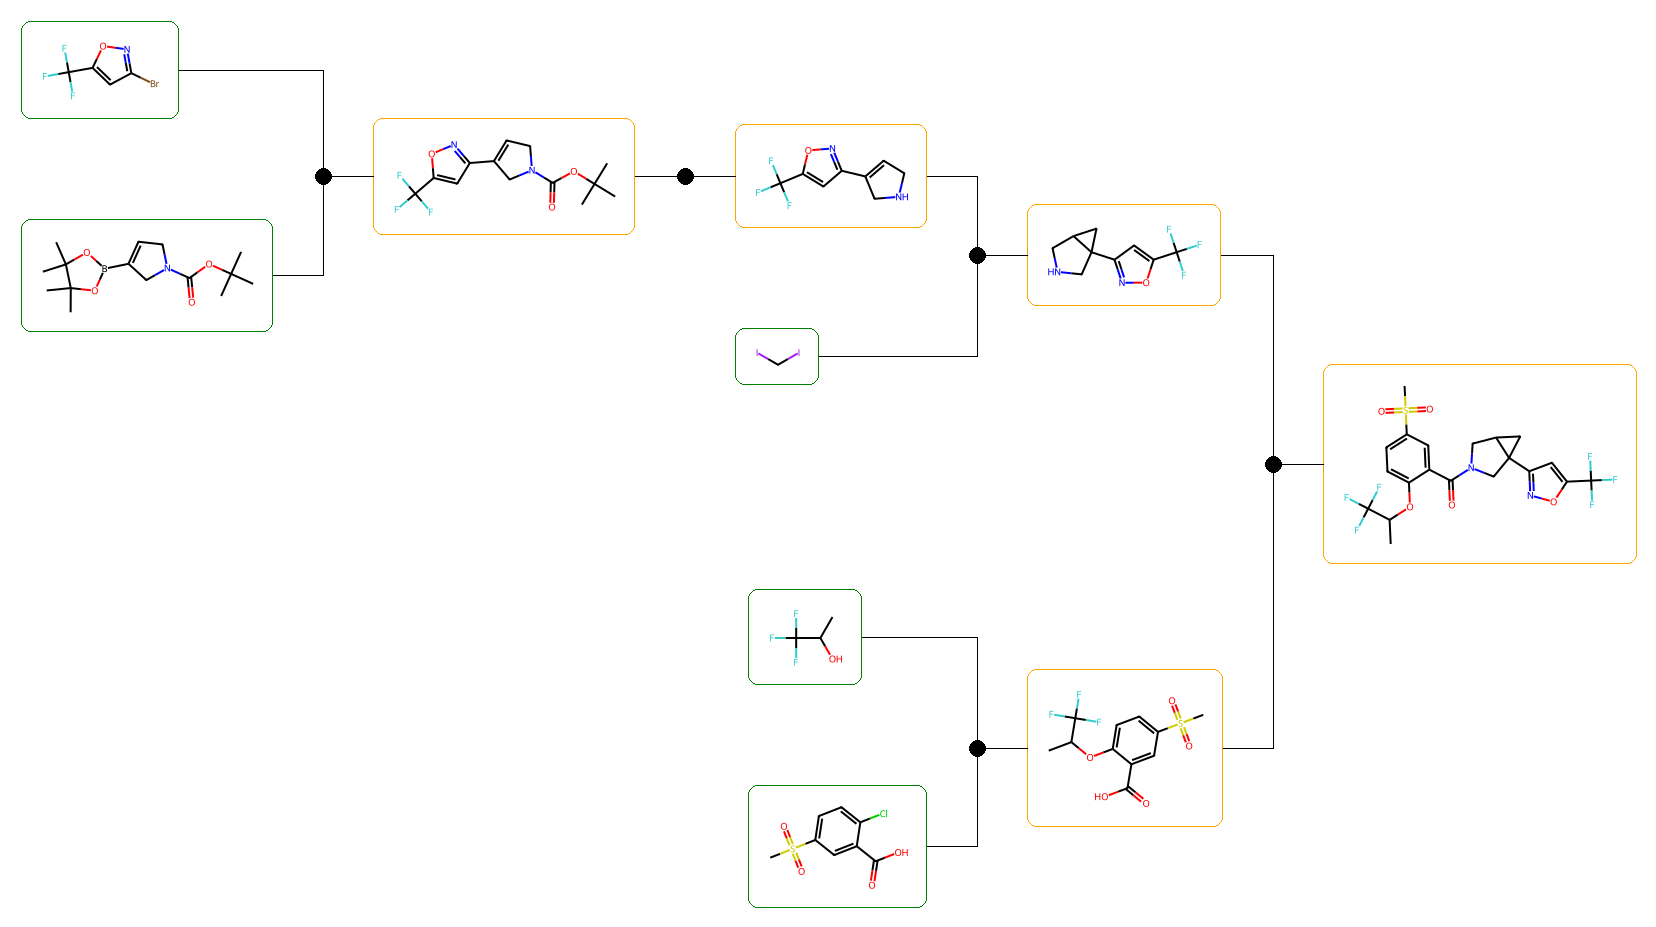

In [170]:
visualize_route(diversity_mcts_df, molecule_index=1, route_index=0)

## save an example josn

In [171]:
import pandas as pd
import json
from aizynthfinder.reactiontree import ReactionTree
from pathlib import Path
from typing import Optional

def save_route_json(
    df: pd.DataFrame, 
    molecule_index: int, 
    route_index: int, 
    save_path: str
) -> bool:
    """
    Extracts a specific reaction route and saves it to disk as a JSON file.
    """
    
    # 1. Validate Molecule Index
    if molecule_index < 0 or molecule_index >= len(df):
        print(f"❌ Error: Molecule index {molecule_index} is out of bounds.")
        return False

    # 2. Extract Data
    try:
        molecule_data = df.iloc[molecule_index]
        routes_list = molecule_data.get('trees')
    except Exception as e:
        print(f"❌ Error accessing dataframe: {e}")
        return False

    # 3. Validate Route Index
    if not isinstance(routes_list, list) or not routes_list:
        print(f"❌ Error: No routes found for molecule {molecule_index}.")
        return False

    if route_index < 0 or route_index >= len(routes_list):
        print(f"❌ Error: Route index {route_index} is out of bounds.")
        return False

    # 4. Save to JSON
    print(f"Saving JSON: Molecule {molecule_index} | Route {route_index}")
    
    try:
        # Get the raw dictionary for the route
        route_data = routes_list[route_index]
        
        # Optional: Validate it by passing it through ReactionTree
        # (This ensures what you are saving is a valid AiZynthFinder tree)
        route_obj = ReactionTree.from_dict(route_data)
        clean_data = route_obj.to_dict()

        path_obj = Path(save_path)
        path_obj.parent.mkdir(parents=True, exist_ok=True)

        with open(path_obj, "w") as f:
            json.dump(clean_data, f, indent=2)
            
        print(f"✅ Successfully saved JSON to: {path_obj.resolve()}")
        return True

    except Exception as e:
        print(f"❌ Error saving JSON: {e}")
        return False


save_path = "/Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/results/mol1_route0.json"
# --- Usage Example ---
save_route_json(
    df=diversity_mcts_df, 
    molecule_index=1, 
    route_index=0, 
    save_path=save_path
)

Saving JSON: Molecule 1 | Route 0
✅ Successfully saved JSON to: /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/results/mol1_route0.json


True

✅ Successfully loaded route from: mol1_route0.json


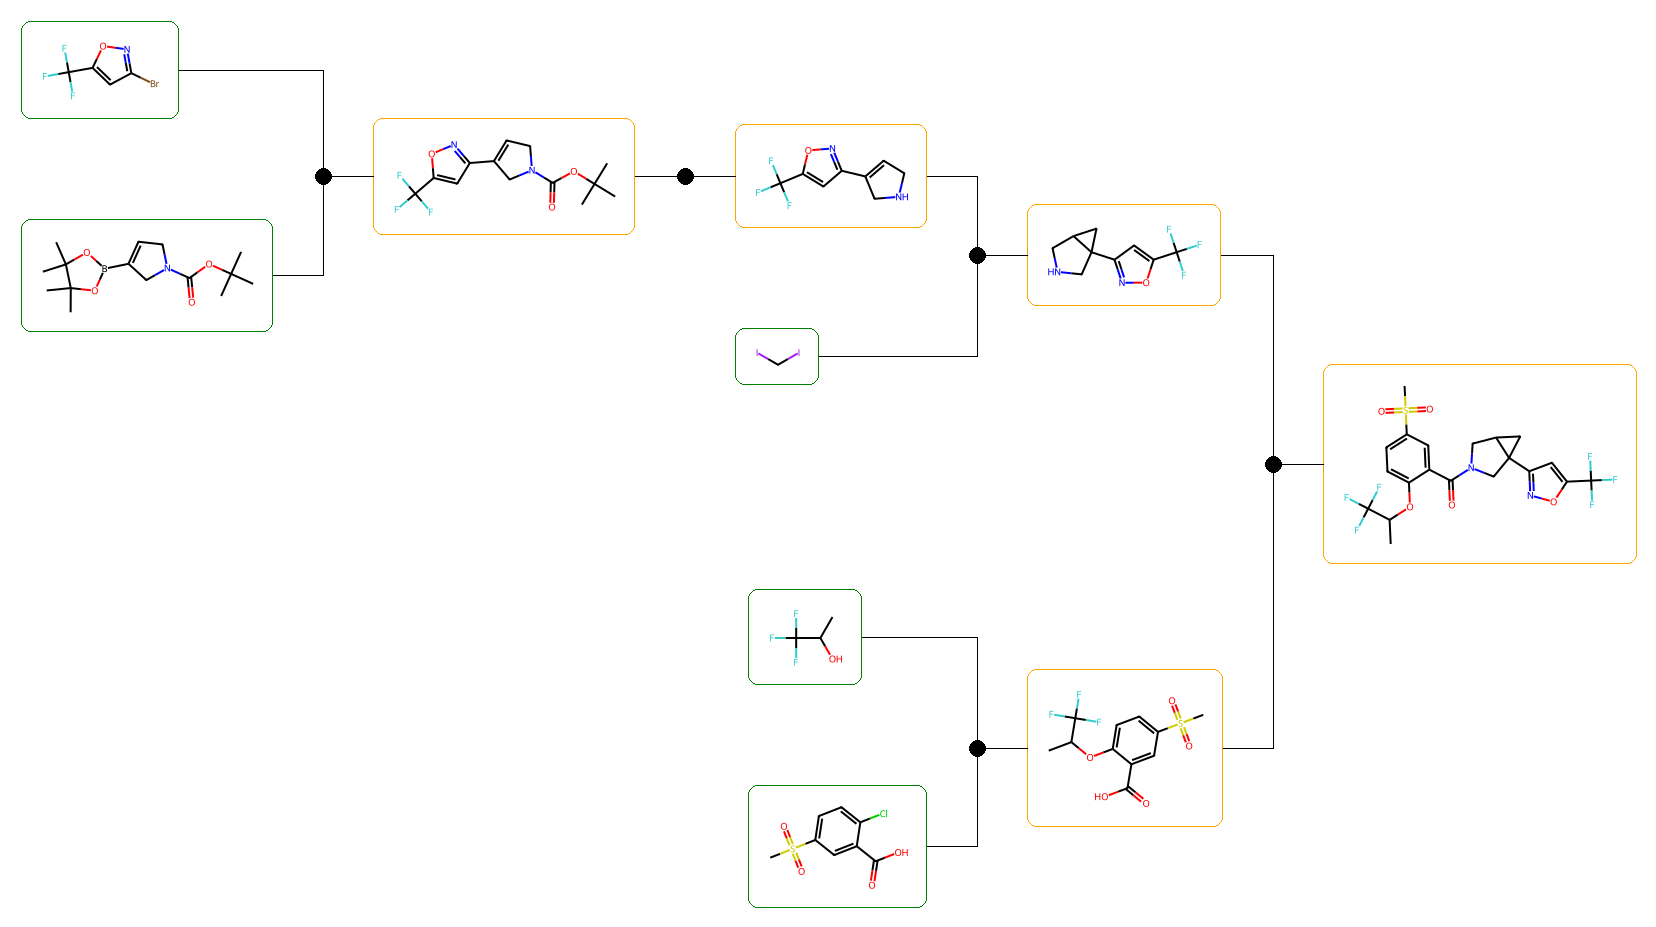

In [172]:
import json
from pathlib import Path
from typing import Union
from IPython.display import display, Image
from aizynthfinder.reactiontree import ReactionTree

def load_and_visualize_route(json_path: str) -> Union[Image, None]:
    """
    Loads a reaction tree from a JSON file and returns an image visualization.

    Parameters:
    -----------
    json_path : str
        The path to the JSON file containing the route data.

    Returns:
    --------
    IPython.display.Image or None if loading fails.
    """
    path_obj = Path(json_path)

    # 1. Check file existence
    if not path_obj.exists():
        print(f"❌ Error: File not found at {path_obj}")
        return None

    try:
        # 2. Load JSON data
        with open(path_obj, "r") as f:
            route_data = json.load(f)

        # 3. Reconstruct the ReactionTree
        # The .from_dict() method rebuilds the tree object from the dictionary
        route = ReactionTree.from_dict(route_data)

        # 4. Generate Image
        image = route.to_image()
        
        print(f"✅ Successfully loaded route from: {path_obj.name}")
        return image

    except json.JSONDecodeError:
        print(f"❌ Error: The file {path_obj.name} is not valid JSON.")
        return None
    except Exception as e:
        print(f"❌ An error occurred: {e}")
        return None

# --- Usage Example ---

# Make sure the path matches where you saved it previously
img = load_and_visualize_route(save_path)

# If you are in a Jupyter Notebook, simply returning 'img' or calling display() works
if img:
    display(img)

### mol 0 zipoli

In [173]:
# Zipolti molecule 0 route
mol = "CS(=O)(=O)OC1=C(C=CC=C1)O/C=C/C2=CC(=CC(=C2)C(=O)NCO)O"
r1 = "COC(=O)C1=CC(=CC(=C1)O)/C=C/OC2=C(C=CC=C2)OS(=O)(=O)C.C(N)O"
r2 = "CC(=O)OC1=CC(=CC(=C1)/C=C/OC2=C(C=CC=C2)OS(=O)(=O)C)C(=O)OC"
r3 = "CC(=O)OC1=CC(=CC(=C1)Br)C(=O)OC.C=COC1=C(C=CC=C1)OS(=O)(=O)C"
r4 = "C=COC1=C(C=CC=C1)O.CS(=O)(=O)Cl"
r5 = "COC(=O)C1=CC(=CC(=C1)O)Br.CC(=O)OC(=O)C"


✅ Successfully loaded route from: zipotli_mol_0_right.json


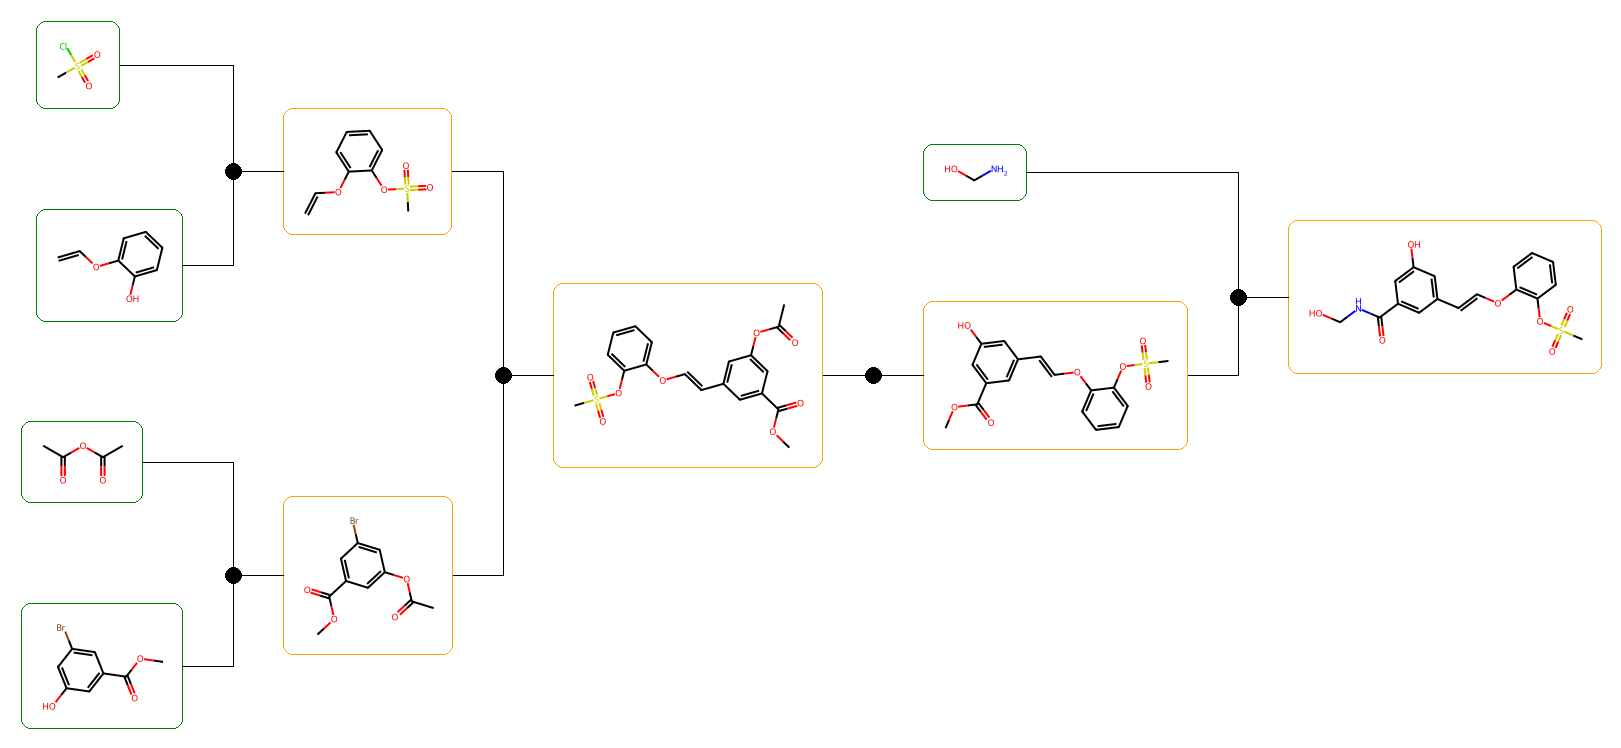

In [174]:
# Make sure the path matches where you saved it previously
img = load_and_visualize_route("/Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/zipotli_paper_routes/zipotli_mol_0_right.json")

# If you are in a Jupyter Notebook, simply returning 'img' or calling display() works
if img:
    display(img)

In [175]:
mol ="CC(C(F)(F)F)OC1=CC=C(C=C1C(=O)N2CC3CC3(C2)C4=NOC(=C4)C(F)(F)F)S(=O)(=O)C"
r1= "CC(C(F)(F)F)OC1=CC=C(C=C1C(=O)O)S(=O)(=O)C.C1=C(C(F)(F)F)ON=C1C23CC3CNC2"
r2= "CC(C(F)(F)F)OC1=CC=C(C=C1C(=O)OC)S(=O)(=O)C"
r3= "CC(C)(C)OC(=O)N1CC2CC2(C1)C3=NOC(=C3)C(F)(F)F"
r4= "CC(C)(C)OC(=O)N1CC2CC2(C=NO)C1.C#CC(F)(F)F"
r5= "CC(C)(C)OC(=O)N1CC2CC2(C1)C=O.NO"

✅ Successfully loaded route from: zipotli_mol_1_right.json


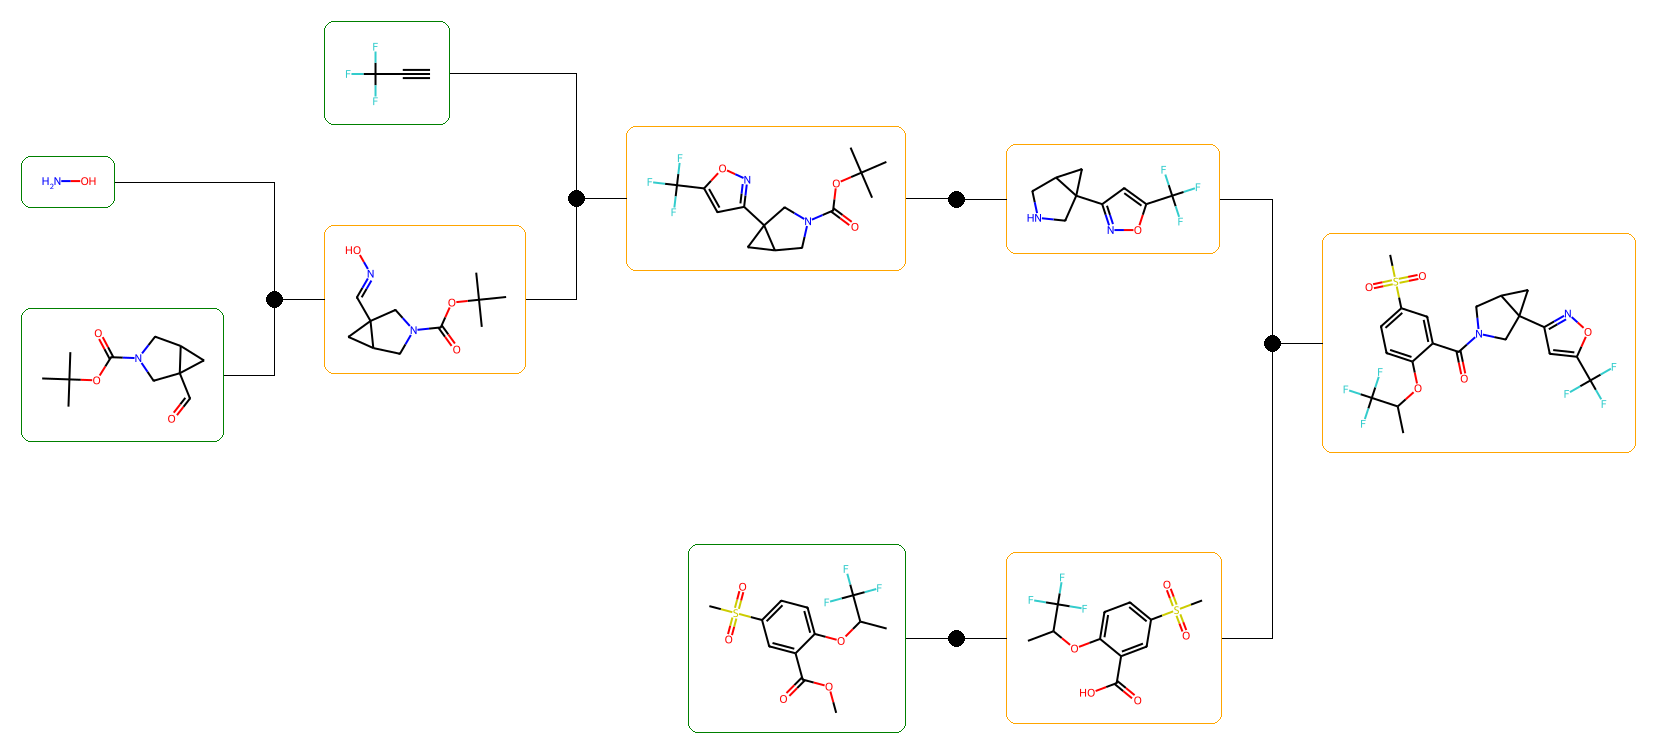

In [176]:
# Make sure the path matches where you saved it previously
img = load_and_visualize_route("/Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/zipotli/zipotli_paper_routes/zipotli_mol_1_right.json")

# If you are in a Jupyter Notebook, simply returning 'img' or calling display() works
if img:
    display(img)